In [1]:
import pandas as pd 
import numpy as np 

In [2]:
df=pd.read_csv("startup_funding.csv")

In [3]:
df.head()

,Sr No,Date dd/mm/yyyy,Startup Name,Industry Vertical,SubVertical,City Location,Investors Name,InvestmentnType,Amount in USD,Remarks
0,1,09/01/2020,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,"20,00,00,000",NaN
1,2,13/01/2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,"80,48,394",NaN
2,3,09/01/2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,"1,83,58,860",NaN
3,4,02/01/2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,"30,00,000",NaN
4,5,02/01/2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,"18,00,000",NaN


In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3044 entries, 0 to 3043
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Sr No              3044 non-null   int64 
 1   Date dd/mm/yyyy    3044 non-null   object
 2   Startup Name       3044 non-null   object
 3   Industry Vertical  2873 non-null   object
 4   SubVertical        2108 non-null   object
 5   City  Location     2864 non-null   object
 6   Investors Name     3020 non-null   object
 7   InvestmentnType    3040 non-null   object
 8   Amount in USD      2084 non-null   object
 9   Remarks            419 non-null    object
dtypes: int64(1), object(9)
memory usage: 237.9+ KB


In [4]:
df.drop(columns=["Remarks"],inplace=True)

In [5]:
df.set_index("Sr No",inplace=True)

In [6]:
df.head()

,Date dd/mm/yyyy,Startup Name,Industry Vertical,SubVertical,City Location,Investors Name,InvestmentnType,Amount in USD
Sr No,,,,,,,,
1,09/01/2020,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,"20,00,00,000"
2,13/01/2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,"80,48,394"
3,09/01/2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,"1,83,58,860"
4,02/01/2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,"30,00,000"
5,02/01/2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,"18,00,000"


In [7]:
df.sample()

,Date dd/mm/yyyy,Startup Name,Industry Vertical,SubVertical,City Location,Investors Name,InvestmentnType,Amount in USD
Sr No,,,,,,,,
1787,19/04/2016,Betaout,eCommerce,customer intelligence and marketing automation...,Noida,"Stanford Angels, LetsVenture, Chennai Angels, ...",Private Equity,"15,00,000"


In [8]:
df["Investors Name"]=df["Investors Name"].fillna("undisclosed")

In [9]:
df.rename(columns={
    "Date dd/mm/yyyy":"date",
    "Startup Name":"startup",
    "Industry Vertical":"vertical",
    "SubVertical":"subvertical",
    "City  Location": "city",
    "Investors Name":"investors",
    "InvestmentnType":"round",
    "Amount in USD":"amount"
    
},inplace=True)

In [10]:
df["amount"]=df["amount"].fillna("0")

In [11]:
df["amount"]

Sr No
1       20,00,00,000
2          80,48,394
3        1,83,58,860
4          30,00,000
5          18,00,000
            ...     
3040       45,00,000
3041        8,25,000
3042       15,00,000
3043               0
3044        1,40,000
Name: amount, Length: 3044, dtype: object

In [12]:
df["amount"]=df["amount"].str.replace(",","")
# df["amount"]=df["amount"].str.replace(r"0+","",regex=True)
df["amount"]=df["amount"].str.lower().str.strip()
df["amount"]=df["amount"].replace(
                                    {"undisclosed":"0",
                                       "unknown":"0",
                                       "":"0"})
# df["amount"]=df["amount"].str.replace("","0")

df["amount"]=df["amount"].str.replace(r"\\x[a-f0-9]{2}","0",regex=True)
df["amount"]=df["amount"].str.replace("\\0\\0935","0").str.replace("\\\\935","0")
df["amount"]=df["amount"].str.replace("\\\\","0")
df["amount"]=df["amount"].str.replace("14342+","0")
df["amount"]=df["amount"].str.replace("\\xan/a","0")
df["amount"]=df["amount"].str.replace('\\0\\0',"0")
df["amount"]=df["amount"].str.replace("14342000+","0")
# ''
df["amount"]=df["amount"].str.replace("0n/a","0")
# df["amount"]=df["amount"].str.replace("","0").str.replace("0u0n0k0n0o0w0n0","0").str.replace("000u000n000k000n000o000w000n000","0")




In [13]:
df["amount"]=df["amount"].astype("float")

In [14]:
df.tail()

,date,startup,vertical,subvertical,city,investors,round,amount
Sr No,,,,,,,,
3040,29/01/2015,Printvenue,NaN,NaN,NaN,Asia Pacific Internet Group,Private Equity,4500000.0
3041,29/01/2015,Graphene,NaN,NaN,NaN,KARSEMVEN Fund,Private Equity,825000.0
3042,30/01/2015,Mad Street Den,NaN,NaN,NaN,"Exfinity Fund, GrowX Ventures.",Private Equity,1500000.0
3043,30/01/2015,Simplotel,NaN,NaN,NaN,MakeMyTrip,Private Equity,0.0
3044,31/01/2015,couponmachine.in,NaN,NaN,NaN,UK based Group of Angel Investors,Seed Funding,140000.0


In [15]:
def usd_to_inr(dollar):
    inr=dollar*82.5
    return inr/10000000

In [16]:
usd_to_inr(14.0)

0.0001155

In [94]:
df.head()

,date,startup,vertical,subvertical,city,investors,round,amount
Sr No,,,,,,,,
1,09/01/2020,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,200000000.0
2,13/01/2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,8048394.0
3,09/01/2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,18358860.0
4,02/01/2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,3000000.0
5,02/01/2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,1800000.0


In [17]:
df["amount"]=df["amount"].apply(usd_to_inr)

In [96]:
df.head()

,date,startup,vertical,subvertical,city,investors,round,amount
Sr No,,,,,,,,
1,09/01/2020,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,1650.000000
2,13/01/2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,66.399250
3,09/01/2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,151.460595
4,02/01/2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,24.750000
5,02/01/2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,14.850000


In [18]:
df["date"]=df["date"].str.replace("05/072018","05/07/2018")
df["date"]=df["date"].str.replace("01/07/015","01/07/2015")
df["date"]=df["date"].str.replace("\\xc2\\xa010/7/2015","02/10/2015")

In [19]:
df["date"]=pd.to_datetime(df["date"],format="%d/%m/%Y",errors="coerce")


In [20]:
df.head()

,date,startup,vertical,subvertical,city,investors,round,amount
Sr No,,,,,,,,
1,2020-01-09,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,1650.000000
2,2020-01-13,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,66.399250
3,2020-01-09,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,151.460595
4,2020-01-02,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,24.750000
5,2020-01-02,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,14.850000


In [21]:
df=df.dropna(subset=["date","vertical","startup","city","investors","round","amount"])

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2856 entries, 1 to 2873
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         2856 non-null   datetime64[ns]
 1   startup      2856 non-null   object        
 2   vertical     2856 non-null   object        
 3   subvertical  2098 non-null   object        
 4   city         2856 non-null   object        
 5   investors    2856 non-null   object        
 6   round        2856 non-null   object        
 7   amount       2856 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(6)
memory usage: 200.8+ KB


In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2856 entries, 1 to 2873
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         2856 non-null   datetime64[ns]
 1   startup      2856 non-null   object        
 2   vertical     2856 non-null   object        
 3   subvertical  2098 non-null   object        
 4   city         2856 non-null   object        
 5   investors    2856 non-null   object        
 6   round        2856 non-null   object        
 7   amount       2856 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(6)
memory usage: 200.8+ KB


In [103]:
df.to_csv("startup_cleaned.csv")

In [23]:
df["year"]=df["date"].dt.year

In [105]:
df[df["investors"].str.contains("Sequoia Capital India")].groupby("year")["amount"].sum()

year
2016     783.750000
2017    5063.850000
2018     374.385000
2019     495.000000
2020     151.460595
Name: amount, dtype: float64

In [106]:
df.head()

,date,startup,vertical,subvertical,city,investors,round,amount,year
Sr No,,,,,,,,,
1,2020-01-09,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,1650.000000,2020
2,2020-01-13,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,66.399250,2020
3,2020-01-09,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,151.460595,2020
4,2020-01-02,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,24.750000,2020
5,2020-01-02,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,14.850000,2020


In [107]:
df[df["investors"].str.contains("Sequoia Capital")].groupby("city")["amount"].sum()

city
Ahmedabad           132.000000
Bangalore          3639.900000
Bengaluru          2043.268095
Chennai            1278.750000
Gurgaon            7234.012500
Gurugram             82.500000
Hyderabad            57.750000
India/Singapore    1864.500000
Jaipur               49.500000
Mumbai             1456.950000
New Delhi          2366.100000
Pune                959.475000
Singapore           495.000000
Name: amount, dtype: float64

<Axes: ylabel='amount'>

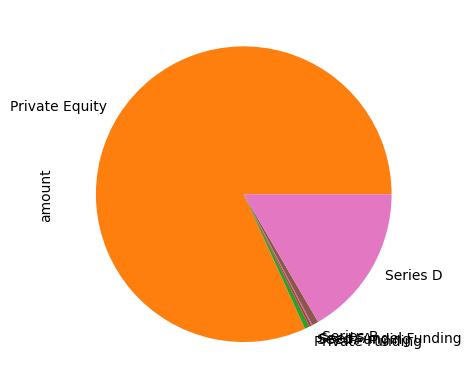

In [108]:
df[df["investors"].str.contains("Sequoia Capital")].groupby("round")["amount"].sum().plot(kind="pie")

In [109]:
sorted(set(df["investors"].str.split(",").sum()))

['',
 ' & Others',
 ' 100 Co-founders Lab and others.',
 ' 122 West Ventures',
 ' 1Crowd',
 ' 3ONE4 Capital Advisors',
 ' 3one4 Capital',
 ' 3one4 Capital Advisors LLP',
 ' 500 Start-Ups',
 ' 500 Startups',
 ' 500 Startups & Other HNIs',
 ' 50K Ventures & others',
 ' 91SpringBoard',
 ' 91springboard',
 ' ABB Technology Ventures',
 ' ABCOM Investments',
 ' AECAL',
 ' AET Fund',
 ' AL Nour International Holdings and Mark V Investments',
 ' ASP Consulting',
 ' AVN Business Solutions',
 ' Aarin Capital',
 ' Aarin Capital & Others',
 ' Aaruha Technology Fund',
 ' Abaran Deep',
 ' Abhai S. Rao',
 ' Abhay Singhal',
 ' Abhijit Bhandari',
 ' Abhinav Patodia',
 ' Abhinav Sinha',
 ' Abhishek Acharya',
 ' Abhishek Goyal',
 ' Abhishek Gupta',
 ' Abhishek Jain',
 ' Abhishekh Goyal',
 ' Abstract Ventures',
 ' Abu Farhan Azmi',
 ' Accel',
 ' Accel India',
 ' Accel Partner',
 ' Accel Partners',
 ' Accel Partners & Others',
 ' Accel Partners & Raghunandan Gangappa',
 ' Accel Partners & existing investor

In [110]:
df[df["investors"].str.contains("Sprout Venture Partners")][["date","startup","vertical","round","amount"]]

,date,startup,vertical,round,amount
Sr No,,,,,
5,2020-01-02,Fashor,Fashion and Apparel,Seed Round,14.85
166,2018-08-01,HealthFin,Finance,Seed/ Angel Funding,0.00


In [111]:
df.head()

,date,startup,vertical,subvertical,city,investors,round,amount,year
Sr No,,,,,,,,,
1,2020-01-09,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,1650.000000,2020
2,2020-01-13,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,66.399250,2020
3,2020-01-09,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,151.460595,2020
4,2020-01-02,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,24.750000,2020
5,2020-01-02,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,14.850000,2020


In [112]:
df[df["investors"].str.contains("Sequoia Capital")].groupby("startup")["amount"].sum().sort_values(ascending=False).head()

startup
Oyo Rooms    2887.50
OYO Rooms    2062.50
Zilingo      1864.50
Grofers      1278.75
BlackBuck    1237.50
Name: amount, dtype: float64

In [113]:
# sorted(df["Investors Name"].unique().tolist())

In [114]:
df[df["investors"].str.contains("")].groupby("vertical")["amount"].sum()

vertical
360-degree view creating platform                            0.000
3D Printer Manufacturer                                     24.750
AI                                                           0.000
API Workflow platform                                        8.250
Accounting                                                  41.250
                                                             ...  
solar products and services marketplace                      0.000
us ticketing and fleet management platform                   0.000
usiness expense management                                   4.125
virtual reality, 3d simulation and stereoscopic products     6.600
visual search and discovery platform                         8.250
Name: amount, Length: 817, dtype: float64

In [115]:
# df["Startup Name"].unique().tolist()

In [116]:
int(df.groupby("startup")["amount"].max().sort_values(ascending=False).head(1).values[0])

32175

In [117]:
int(df.groupby("startup")["amount"].sum().mean())

129

<Axes: xlabel='vertical'>

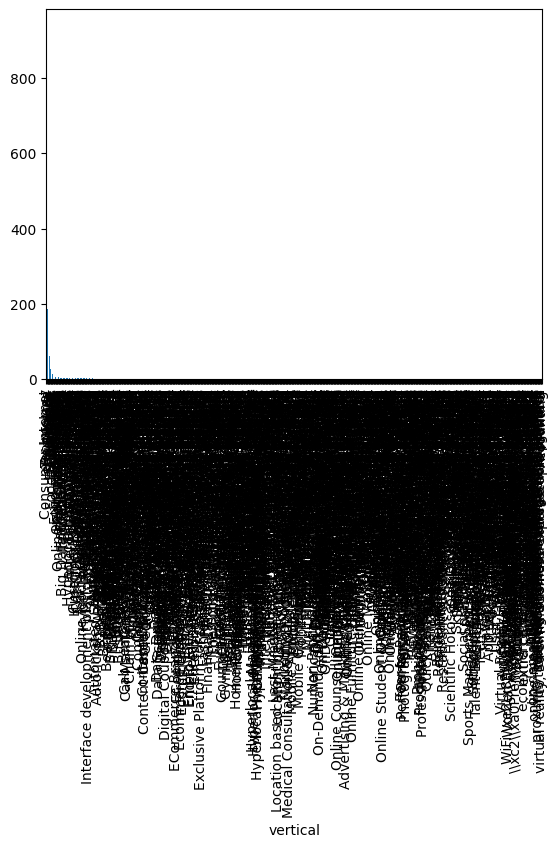

In [118]:
df.groupby(["vertical"])["vertical"].value_counts().sort_values(ascending=False).plot(kind="bar")

<Axes: ylabel='amount'>

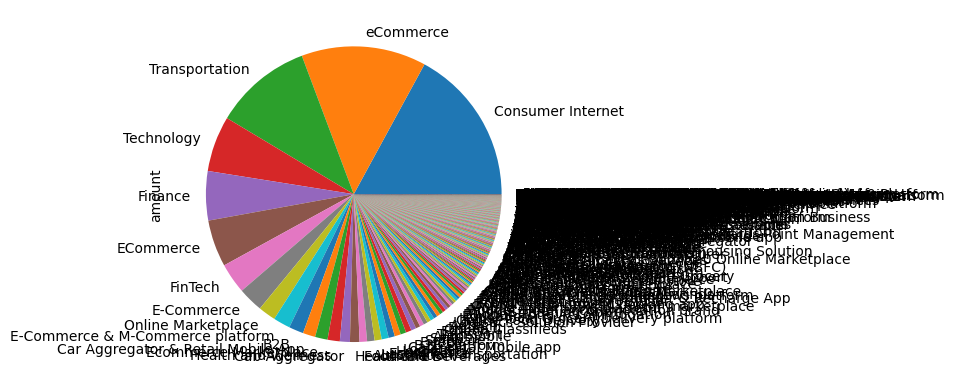

In [119]:
df.groupby("vertical")["amount"].sum().sort_values(ascending=False).plot(kind="pie")

In [120]:
df.groupby("round")["round"].nunique().index

Index(['Angel', 'Angel / Seed Funding', 'Angel Funding', 'Angel Round',
       'Bridge Round', 'Corporate Round', 'Debt', 'Debt Funding',
       'Debt and Preference capital', 'Debt-Funding', 'Equity',
       'Equity Based Funding', 'Funding Round', 'Inhouse Funding',
       'Maiden Round', 'Mezzanine', 'Pre Series A', 'Pre-Series A',
       'Pre-series A', 'Private', 'Private Equity', 'Private Equity Round',
       'Private Funding', 'PrivateEquity', 'Seed', 'Seed / Angel Funding',
       'Seed / Angle Funding', 'Seed Funding', 'Seed Funding Round',
       'Seed Round', 'Seed funding', 'Seed/ Angel Funding',
       'Seed/Angel Funding', 'Series A', 'Series B', 'Series B (Extension)',
       'Series C', 'Series D', 'Series E', 'Series F', 'Series G', 'Series H',
       'Series J', 'Single Venture', 'Structured Debt', 'Term Loan', 'Venture',
       'Venture - Series Unknown', 'Venture Round', 'pre-Series A',
       'pre-series A'],
      dtype='object', name='round')

In [121]:
df.head()

,date,startup,vertical,subvertical,city,investors,round,amount,year
Sr No,,,,,,,,,
1,2020-01-09,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,1650.000000,2020
2,2020-01-13,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,66.399250,2020
3,2020-01-09,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,151.460595,2020
4,2020-01-02,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,24.750000,2020
5,2020-01-02,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,14.850000,2020


In [122]:
df.groupby(["city","round"])

In [123]:
df["startup"].nunique()

2326

In [124]:
df.head()

,date,startup,vertical,subvertical,city,investors,round,amount,year
Sr No,,,,,,,,,
1,2020-01-09,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,1650.000000,2020
2,2020-01-13,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,66.399250,2020
3,2020-01-09,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,151.460595,2020
4,2020-01-02,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,24.750000,2020
5,2020-01-02,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,14.850000,2020


In [125]:
data=df.groupby(["year","startup"])["amount"].sum().reset_index()

In [126]:
data.tail()

,year,startup,amount
2677,2020,Mamaearth,151.460595
2678,2020,Pando,74.250000
2679,2020,Shuttl,66.399250
2680,2020,Zomato,1237.500000
2681,2020,https://www.wealthbucket.in/,24.750000


In [127]:
data[data["year"]==2015].sort_values(by="amount",ascending=False).head(1)["startup"].values[0]

'Flipkart.com'

In [128]:
data[data["year"]==2016].sort_values(by="amount",ascending=False).head(1)[["startup","year"]]

,startup,year
1402,Snapdeal,2016


In [129]:
data[data["year"]==2017].sort_values(by="amount",ascending=False).head(1)["startup"].values[0]

'Flipkart'

In [130]:
data[data["year"]==2018].sort_values(by="amount",ascending=False).head(1)["startup"].values[0]

'True North'

In [131]:
data[data["year"]==2019].sort_values(by="amount",ascending=False).head(1)["startup"].values[0]

'Rapido Bike Taxi'

In [132]:
data[data["year"]==2020].sort_values(by="amount",ascending=False).head(1)["startup"].values[0]

'BYJU’S'

startup analysis

In [133]:
df["startup"]

Sr No
1                             BYJU’S
2                             Shuttl
3                          Mamaearth
4       https://www.wealthbucket.in/
5                             Fashor
                    ...             
2869                          Tracxn
2870                            Dazo
2871                        Tradelab
2872                          PiQube
2873                 Travel Triangle
Name: startup, Length: 2856, dtype: object

In [134]:
df.head()

,date,startup,vertical,subvertical,city,investors,round,amount,year
Sr No,,,,,,,,,
1,2020-01-09,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,1650.000000,2020
2,2020-01-13,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,66.399250,2020
3,2020-01-09,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,151.460595,2020
4,2020-01-02,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,24.750000,2020
5,2020-01-02,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,14.850000,2020


In [141]:
df[df["startup"]=="Mamaearth"]["vertical"].values[0]

'E-commerce'

In [144]:
df[df["startup"]=="Mamaearth"]["city"].values[0]

'Bengaluru'

In [148]:
df[df["startup"]=="Mamaearth"][["round","amount"]]

,round,amount
Sr No,,
3,Series B,151.460595


similar company on the basis of same round

In [154]:
data_similar_startup=df.groupby(["round","startup"])["amount"].sum().reset_index()

In [156]:
data_similar_startup

,round,startup,amount
0,Angel,WizCounsel,1.19625
1,Angel / Seed Funding,CleverTap,0.00000
2,Angel / Seed Funding,DAAKI,0.00000
3,Angel / Seed Funding,Glassic,0.00000
4,Angel / Seed Funding,Kuants,0.66000
...,...,...,...
2516,Venture Round,INDwealth,123.75000
2517,Venture Round,Shuttl,41.25000
2518,pre-Series A,Agara Labs,20.62500
2519,pre-Series A,Recykal,214.50000


In [163]:
data_similar_startup[data_similar_startup["round"]=="pre-Series A"]["startup"].values

array(['Agara Labs', 'Recykal'], dtype=object)